<a href="https://colab.research.google.com/github/gizemetyemezge/two-machine-DES-Reinforcement-Learning/blob/main/DES_RL_Uretim_Hatti_Optimizasyonu_ANA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# İki Makineli Üretim Hattında Ayrık Olay Simülasyonu ve Pekiştirmeli Öğrenme ile Bakım Karar Optimizasyonu

**Alan:** Yalın üretim / metal sektörü
**Simülasyon:** Ayrık olay simülasyonu (Discrete Event Simulation, DES) — SimPy
**Veri:** `hybrid_manufacturing_categorical.csv` (açık üretim veri seti, 1000 iş kaydı, 5 makine, 5 operasyon tipi)
**Yapay zekâ:** Reinforcement Learning (Pekiştirmeli Öğrenme)
**Senaryo:** İki makineli seri üretim hattı (M1 → M2)
**Amaç:** Bakım kararını (üretime devam et / önleyici bakım yap) ve — ikinci aşamada — üretim sıralaması kararını RL ile optimize etmek

---

## Proje Yol Haritası

1. **Veri Keşfi ve İstatistiksel Dağılım Çıkarımı** *(bu bölüm)*
2. İki Makineli SimPy DES Modeli
3. Baseline Performans Metrikleri
4. Bakım Kararı için RL Ortamı (Gymnasium)
5. RL Ajanının Eğitimi ve Karşılaştırma
6. (Genişletme) Üretim Sıralaması Kararı
7. Sonuçlar ve Değerlendirme

---

## 1. Veri Keşfi ve İstatistiksel Dağılım Çıkarımı

Bu bölümde veri setindeki her bir alanın dağılımını inceleyip, DES modelinde kullanılacak
stokastik üreteçleri (işlem süresi, arıza olasılığı, gecikme süresi vb.) istatistikleri var

In [33]:
import json
import os
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib as mpl


CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
               "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
STATUS = {"good": "#0ca30c", "warning": "#fab219", "serious": "#ec835a", "critical": "#d03b3b"}
SURFACE, INK, INK_SEC, INK_MUTED, GRID, BASELINE = (
    "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7")

def apply_style():
    mpl.rcParams.update({
        "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
        "axes.edgecolor": BASELINE, "axes.labelcolor": INK_SEC, "text.color": INK,
        "xtick.color": INK_MUTED, "ytick.color": INK_MUTED, "grid.color": GRID,
        "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold",
        "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
        "grid.linewidth": 0.8, "axes.axisbelow": True, "legend.frameon": False,
    })

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    if title: ax.set_title(title, loc="left", pad=10)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.7)
    ax.grid(axis="x", visible=False)
    return ax

apply_style()
pd.set_option('display.max_columns', None)


DATA_PATH = "data/hybrid_manufacturing_categorical.csv"
if not os.path.exists(DATA_PATH):
    candidates = [f for f in os.listdir(".") if f.lower().endswith(".csv")]
    if candidates:
        DATA_PATH = candidates[0]
    else:
        try:
            from google.colab import files
            print("CSV dosyasi bulunamadi -> 'hybrid_manufacturing_categorical.csv' dosyasini secin:")
            uploaded = files.upload()
            DATA_PATH = list(uploaded.keys())[0]
        except ImportError:
            raise FileNotFoundError(
                "hybrid_manufacturing_categorical.csv bulunamadi. Dosyayi notebook ile "
                "ayni klasore (veya data/ alt klasorune) koyun."
            )
print("Kullanilan veri dosyasi:", DATA_PATH)


Kullanilan veri dosyasi: hybrid_manufacturing_categorical.csv


### 1.1 Veri Setine Genel Bakış

In [34]:
df = pd.read_csv(DATA_PATH)
for c in ["Scheduled_Start", "Scheduled_End", "Actual_Start", "Actual_End"]:
    df[c] = pd.to_datetime(df[c])

print("Boyut:", df.shape)
df.head()


Boyut: (1000, 13)


,Job_ID,Machine_ID,Operation_Type,Material_Used,Processing_Time,Energy_Consumption,Machine_Availability,Scheduled_Start,Scheduled_End,Actual_Start,Actual_End,Job_Status,Optimization_Category
0,J001,M01,Grinding,3.17,76,11.42,96,2023-03-18 08:00:00,2023-03-18 09:16:00,2023-03-18 08:05:00,2023-03-18 09:21:00,Completed,Moderate Efficiency
1,J002,M01,Grinding,3.35,79,6.61,84,2023-03-18 08:10:00,2023-03-18 09:29:00,2023-03-18 08:20:00,2023-03-18 09:39:00,Delayed,Low Efficiency
2,J003,M04,Additive,2.29,56,11.11,92,2023-03-18 08:20:00,2023-03-18 09:16:00,NaT,NaT,Failed,Low Efficiency
3,J004,M04,Grinding,1.76,106,12.50,95,2023-03-18 08:30:00,2023-03-18 10:16:00,2023-03-18 08:35:00,2023-03-18 10:21:00,Completed,Moderate Efficiency
4,J005,M01,Lathe,1.90,46,8.13,88,2023-03-18 08:40:00,2023-03-18 09:26:00,2023-03-18 08:42:00,2023-03-18 09:28:00,Completed,High Efficiency


In [35]:
df.describe(include='all').T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Job_ID,1000,1000,J1000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Machine_ID,1000,5,M01,212,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Operation_Type,1000,5,Lathe,212,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Material_Used,1000.0,NaN,NaN,NaN,3.02648,1.01,2.04,3.08,4.0425,5.0,1.148139
Processing_Time,1000.0,NaN,NaN,NaN,71.384,20.0,48.0,72.0,96.0,120.0,28.48438
Energy_Consumption,1000.0,NaN,NaN,NaN,8.52134,2.01,5.3975,8.56,11.6725,14.98,3.669941
Machine_Availability,1000.0,NaN,NaN,NaN,89.163,80.0,84.0,89.0,94.0,99.0,5.757567
Scheduled_Start,1000,NaN,NaN,NaN,2023-03-21 19:15:00,2023-03-18 08:00:00,2023-03-20 01:37:30,2023-03-21 19:15:00,2023-03-23 12:52:30,2023-03-25 06:30:00,NaN
Scheduled_End,1000,NaN,NaN,NaN,2023-03-21 20:26:23.040000,2023-03-18 09:16:00,2023-03-20 02:27:45,2023-03-21 20:18:00,2023-03-23 14:05:30,2023-03-25 08:21:00,NaN
Actual_Start,871,NaN,NaN,NaN,2023-03-21 18:59:49.047072512,2023-03-18 08:05:00,2023-03-20 01:41:30,2023-03-21 17:52:00,2023-03-23 12:54:30,2023-03-25 06:29:00,NaN


**Gözlemler:**
- 1000 iş kaydı, 5 makine (M01–M05), 5 operasyon tipi (Lathe, Grinding, Milling, Additive, Drilling).
- `Actual_Start` / `Actual_End` alanlarında 129 eksik değer var — bunlar tam olarak `Job_Status == 'Failed'`
  olan işlere karşılık geliyor (iş arızalanıp tamamlanamadığı için gerçekleşen zaman kaydedilmemiş).
- `Job_Status`: Completed / Delayed / Failed — DES modelimizdeki "arıza" ve "gecikme" olaylarının kaynağı.

In [36]:
missing = df.isna().sum()
failed_missing = df.loc[df['Job_Status']=='Failed', ['Actual_Start','Actual_End']].isna().sum()
print("Eksik değerler:\n", missing[missing>0])
print("\nFailed işlerde eksik Actual_Start/End:\n", failed_missing)


Eksik değerler:
 Actual_Start    129
Actual_End      129
dtype: int64

Failed işlerde eksik Actual_Start/End:
 Actual_Start    129
Actual_End      129
dtype: int64


### 1.2 İşlem Süresi Dağılımı (`Processing_Time`)

Önce operasyon tipine göre işlem süresinin farklılaşıp farklılaşmadığına bakıyoruz.

In [37]:
df.groupby('Operation_Type')['Processing_Time'].describe()


,count,mean,std,min,25%,50%,75%,max
Operation_Type,,,,,,,,
Additive,190.0,70.610526,29.457994,20.0,45.5,70.0,98.75,120.0
Drilling,189.0,71.470899,27.858981,21.0,50.0,76.0,94.00,120.0
Grinding,208.0,73.365385,29.288357,20.0,50.0,74.5,100.25,120.0
Lathe,212.0,71.169811,28.797206,20.0,46.0,72.0,97.00,120.0
Milling,201.0,70.208955,27.098452,21.0,47.0,71.0,93.00,120.0


Ortalama ve standart sapmalar operasyon tipleri arasında istatistiksel olarak
ayırt edilemeyecek kadar yakın (~70–73 dk ortalama, ~28 dk std). Bu da veri setinin
işlem süresini operasyon tipinden bağımsız, tek bir dağılımdan ürettiğini düşündürüyor.
Min=20, max=120, ortalama≈71.4, std≈28.5 değerleri **Uniform(20, 120)** dağılımının
teorik değerleriyle (ortalama=70, std=28.87) çok yakın — bunu Kolmogorov–Smirnov testiyle
doğruluyoruz.

KS testi (Processing_Time vs Uniform(20,120)): statistic=0.0410, p-value=0.0674
-> p > 0.05: Uniform(20,120) dk hipotezi reddedilemiyor.


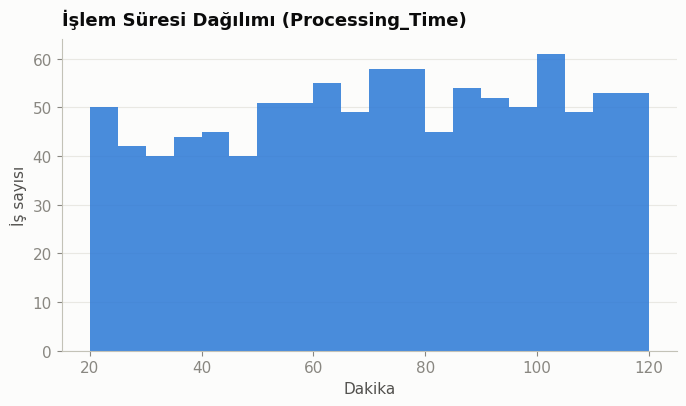

In [38]:
pt = df['Processing_Time'].values
ks = stats.kstest(pt, 'uniform', args=(20, 100))  # scipy uniform(loc, scale) -> [20, 20+100]
print(f"KS testi (Processing_Time vs Uniform(20,120)): statistic={ks.statistic:.4f}, p-value={ks.pvalue:.4f}")
print("-> p > 0.05: Uniform(20,120) dk hipotezi reddedilemiyor.")

fig, ax = plt.subplots(figsize=(7,4.2))
ax.hist(pt, bins=20, color=CATEGORICAL[0], alpha=0.85)
style_ax(ax, "İşlem Süresi Dağılımı (Processing_Time)", "Dakika", "İş sayısı")
fig.tight_layout()
plt.show()


### 1.3 İş Durumu Dağılımı (`Job_Status`) — Arıza ve Gecikme Oranları

DES modelimizdeki en kritik stokastik olaylar: bir işin **zamanında tamamlanması (Completed)**,
**gecikmeli tamamlanması (Delayed)** ya da **arızalanıp başarısız olması (Failed)**.

Job_Status
Completed    673
Delayed      198
Failed       129
Name: count, dtype: int64

Yüzde:
 Job_Status
Completed    67.3
Delayed      19.8
Failed       12.9
Name: count, dtype: float64


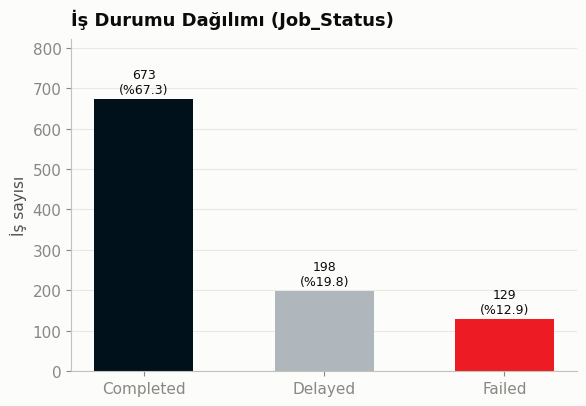

In [39]:
order = ["Completed", "Delayed", "Failed"]
colors_map = {"Completed": "#01111B", "Delayed": "#AFB7BC", "Failed": "#ED1C24"}
counts = df['Job_Status'].value_counts()
probs = (counts / len(df) * 100).round(1)
print(counts)
print("\nYüzde:\n", probs)

fig, ax = plt.subplots(figsize=(6,4.2))
vals = [counts.get(o,0) for o in order]
bars = ax.bar(order, vals, color=[colors_map[o] for o in order], width=0.55)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+8, f"{v}\n(%{100*v/len(df):.1f})", ha='center', va='bottom', fontsize=9)
style_ax(ax, "İş Durumu Dağılımı (Job_Status)", None, "İş sayısı")
ax.set_ylim(0, max(vals)*1.22)
fig.tight_layout()
plt.show()


Genel oranlar: **%67.3 Completed, %19.8 Delayed, %12.9 Failed**.

Bu oranların operasyon tipine veya makineye göre anlamlı şekilde değişip değişmediğini
ki-kare bağımsızlık testiyle kontrol ediyoruz — DES modelinde arıza olasılığını
makineden/operasyondan bağımsız, sabit bir olasılık olarak mı yoksa makineye özgü mü
tanımlayacağımızı belirlemek için.

Job_Status ~ Operation_Type ki-kare: chi2=3.676, p=0.8851
Job_Status ~ Machine_ID     ki-kare: chi2=12.091, p=0.1472

-> Her iki p-değeri de 0.05'in üzerinde: İş durumu istatistiksel olarak
   operasyon tipinden ve makineden BAĞIMSIZ. Bu nedenle DES modelinde sabit
   olasılıklı bir durum dağılımı (0.673 / 0.198 / 0.129) kullanmak savunulabilir.


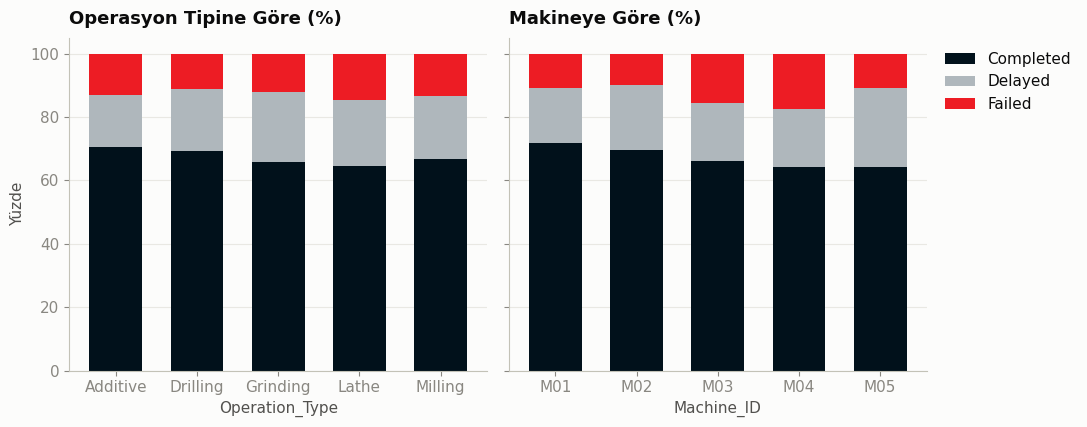

In [40]:
ct_op = pd.crosstab(df['Operation_Type'], df['Job_Status'])
chi2_op, p_op, _, _ = stats.chi2_contingency(ct_op)
ct_m = pd.crosstab(df['Machine_ID'], df['Job_Status'])
chi2_m, p_m, _, _ = stats.chi2_contingency(ct_m)
print(f"Job_Status ~ Operation_Type ki-kare: chi2={chi2_op:.3f}, p={p_op:.4f}")
print(f"Job_Status ~ Machine_ID     ki-kare: chi2={chi2_m:.3f}, p={p_m:.4f}")
print("\n-> Her iki p-değeri de 0.05'in üzerinde: İş durumu istatistiksel olarak")
print("   operasyon tipinden ve makineden BAĞIMSIZ. Bu nedenle DES modelinde sabit")
print("   olasılıklı bir durum dağılımı (0.673 / 0.198 / 0.129) kullanmak savunulabilir.")

fig, axes = plt.subplots(1, 2, figsize=(11,4.4), sharey=True)
props_op = pd.crosstab(df['Operation_Type'], df['Job_Status'], normalize='index')[order]*100
props_op.plot(kind='bar', stacked=True, ax=axes[0], color=[colors_map[o] for o in order], width=0.65, legend=False)
style_ax(axes[0], "Operasyon Tipine Göre (%)", None, "Yüzde")
axes[0].tick_params(axis='x', rotation=0)
props_m = pd.crosstab(df['Machine_ID'], df['Job_Status'], normalize='index')[order]*100
props_m.plot(kind='bar', stacked=True, ax=axes[1], color=[colors_map[o] for o in order], width=0.65)
style_ax(axes[1], "Makineye Göre (%)", None, None)
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(loc='upper left', bbox_to_anchor=(1.01,1.0))
fig.tight_layout()
plt.show()


### 1.4 Gecikme Süresi Dağılımı (Delayed işler)

`Delayed` olarak işaretlenen işlerde planlanan başlangıç zamanı ile gerçekleşen başlangıç
zamanı arasındaki fark (`Actual_Start - Scheduled_Start`).

count    198.000000
mean      20.146465
std        6.273283
min       10.000000
25%       14.000000
50%       21.000000
75%       26.000000
max       30.000000
dtype: float64

KS testi (delay vs Uniform(10,30)): statistic=0.0843, p-value=0.1128


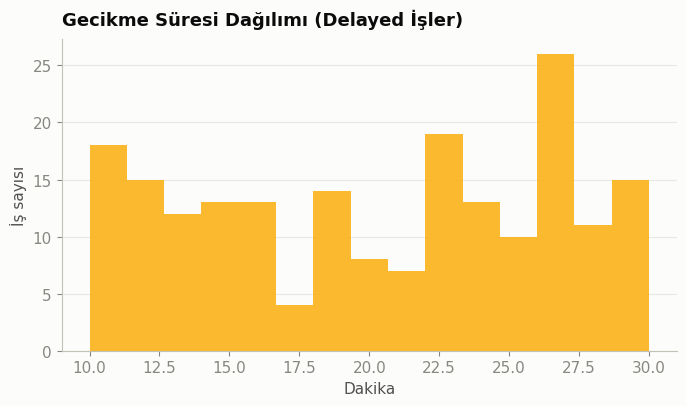

In [41]:
df['start_delay_min'] = (df['Actual_Start'] - df['Scheduled_Start']).dt.total_seconds() / 60
delayed = df[df['Job_Status']=='Delayed']
delay_vals = delayed['start_delay_min'].values
print(pd.Series(delay_vals).describe())

ks_delay = stats.kstest(delay_vals, 'uniform', args=(10, 20))
print(f"\nKS testi (delay vs Uniform(10,30)): statistic={ks_delay.statistic:.4f}, p-value={ks_delay.pvalue:.4f}")

fig, ax = plt.subplots(figsize=(7,4.2))
ax.hist(delay_vals, bins=15, color=STATUS['warning'], alpha=0.9)
style_ax(ax, "Gecikme Süresi Dağılımı (Delayed İşler)", "Dakika", "İş sayısı")
fig.tight_layout()
plt.show()


Gecikme süresi min=10, max=30, ortalama≈20.1 dk — **Uniform(10, 30) dk** dağılımıyla tutarlı.
Bu değeri DES modelinde "hafif duruş / bekleme" senaryosu için ek süre olarak kullanacağız.

`Completed` işlerde ise başlangıç sapması çok küçük (yaklaşık ±5 dk, ölçüm/yuvarlama gürültüsü) —
bu işler pratikte planlandığı gibi ilerliyor.

In [42]:
completed = df[df['Job_Status']=='Completed']
print(completed['start_delay_min'].describe())


count    673.000000
mean      -0.145617
std        3.138122
min       -5.000000
25%       -3.000000
50%        0.000000
75%        2.000000
max        5.000000
Name: start_delay_min, dtype: float64


### 1.5 Makine Kullanılabilirliği (`Machine_Availability`)

Bu alan yüzde cinsinden (80–99 arası) ve muhtemelen makinenin genel çalışabilirlik oranını
(uptime) temsil ediyor. DES modelinde bunu makine bazlı bir "temel sağlamlık" parametresi
olarak kullanabiliriz (ör. bakım aralığı/MTBF ile ilişkilendirerek).

Ki-kare uygunluk testi (ayrık Uniform(80,99)): chi2=33.800, p=0.0194
                 mean       std
Machine_ID                     
M01         89.141509  5.489220
M02         89.147619  6.097464
M03         89.419355  5.531869
M04         88.844221  5.909319
M05         89.284974  5.763267


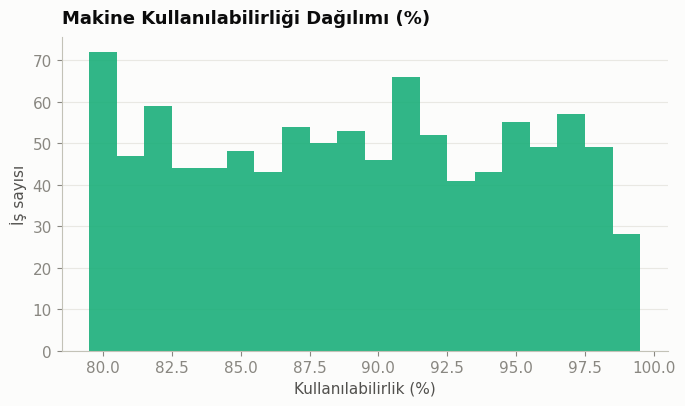

In [43]:
ma = df['Machine_Availability'].values
vals_u, counts_u = np.unique(ma, return_counts=True)
chi2_ma, p_ma = stats.chisquare(counts_u, np.full(len(vals_u), len(ma)/len(vals_u)))
print(f"Ki-kare uygunluk testi (ayrık Uniform(80,99)): chi2={chi2_ma:.3f}, p={p_ma:.4f}")
print(df.groupby('Machine_ID')['Machine_Availability'].agg(['mean','std']))

fig, ax = plt.subplots(figsize=(7,4.2))
bins = np.arange(79.5, 100.5, 1)
ax.hist(ma, bins=bins, color=CATEGORICAL[2], alpha=0.9)
style_ax(ax, "Makine Kullanılabilirliği Dağılımı (%)", "Kullanılabilirlik (%)", "İş sayısı")
fig.tight_layout()
plt.show()


Yaklaşık ayrık-uniform(80,99) — makineler arasında anlamlı fark yok ve `Job_Status` ile
korelasyonu da zayıf (bkz. bir alt bölüm). Bu yüzden bu alanı DES'te doğrudan bir karar
değişkeni olarak değil, betimleyici/yardımcı bir gösterge olarak ele alacağız.

### 1.6 Varış Süreci (Interarrival Time)

İşlerin sisteme giriş sıklığını `Scheduled_Start` zaman damgalarından çıkarıyoruz.

In [44]:
d_sorted = df.sort_values('Scheduled_Start')
interarrival = d_sorted['Scheduled_Start'].diff().dt.total_seconds().dropna() / 60
print(interarrival.describe())


count    999.0
mean      10.0
std        0.0
min       10.0
25%       10.0
50%       10.0
75%       10.0
max       10.0
Name: Scheduled_Start, dtype: float64


Planlanan varışlar arasında **sabit 10 dakika** var (std=0) — veri seti, işlerin
deterministik/düzenli bir programa göre (her 10 dakikada bir yeni iş) planlandığı bir
üretim ortamını temsil ediyor. DES modelinde bunu iki şekilde ele alabiliriz:

1. **Deterministik varış** (D): her 10 dakikada bir yeni iş — veriye en sadık yaklaşım.
2. **Stokastik varış** (M, Poisson süreci, ortalama 10 dk): gerçek üretim hatlarında talep
   değişkenliğini temsil etmek için yaygın kullanılan bir alternatif.

Simülasyonumuzda **her iki modu da destekleyeceğiz** (varsayılan: deterministik, veriye sadık);
RL ortamında değişkenliği test etmek istersek stokastik moda geçebileceğiz.

### 1.7 Enerji Tüketimi (`Energy_Consumption`)

Yalın üretim / sürdürülebilirlik açısından ilgi çekici bir yardımcı metrik — DES çıktısında
takip edip raporlayacağız (RL ödül fonksiyonuna doğrudan dahil etmiyoruz, ileride genişletme
olarak eklenebilir).

KS testi (Energy_Consumption vs Uniform(2.01,14.98)): statistic=0.0211, p-value=0.7570


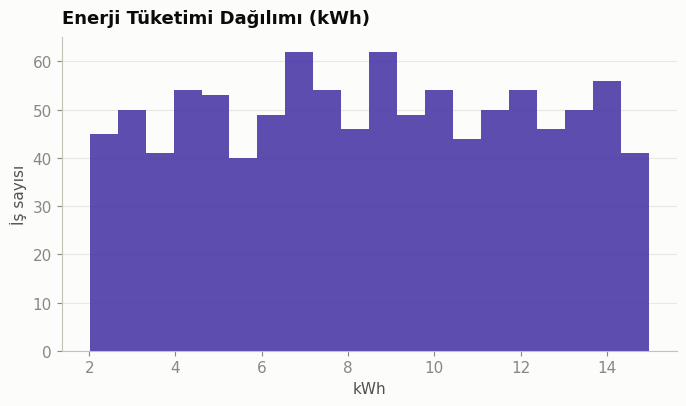

In [45]:
ec = df['Energy_Consumption'].values
ks_ec = stats.kstest(ec, 'uniform', args=(2.01, 12.97))
print(f"KS testi (Energy_Consumption vs Uniform(2.01,14.98)): statistic={ks_ec.statistic:.4f}, p-value={ks_ec.pvalue:.4f}")

fig, ax = plt.subplots(figsize=(7,4.2))
ax.hist(ec, bins=20, color=CATEGORICAL[6], alpha=0.9)
style_ax(ax, "Enerji Tüketimi Dağılımı (kWh)", "kWh", "İş sayısı")
fig.tight_layout()
plt.show()


### 1.8 Bulguların Özeti — Veri Setinin Doğası Hakkında Önemli Bir Not

Yukarıdaki testler bir arada değerlendirildiğinde: `Processing_Time`, `Energy_Consumption`,
`Material_Used` ve `Machine_Availability` alanlarının hepsi kendi aralıklarında **yaklaşık
uniform dağılıma** çok yakın duruyor ve `Job_Status` (Completed/Delayed/Failed) hem operasyon
tipinden hem de makineden **istatistiksel olarak bağımsız** görünüyor (ki-kare testleri,
p > 0.05). Planlanan varışlar arası süre de tam olarak sabit (10 dk).

Bu, veri setinin **sentetik olarak, çoğunlukla bağımsız uniform/ kategorik rastgele
değişkenlerle üretildiğine** işaret ediyor (Kaggle'da yaygın olan sentetik üretim veri
setlerinin tipik bir özelliği). Bu bizim için iki açıdan önemli:

1. **Dürüstlük ilkesi:** Simülasyonumuzun parametrelerini bu ampirik dağılımlardan türeteceğiz
   ve bunu açıkça belirteceğiz — "gerçek bir fabrikanın parmak izi" değil, **veriden istatistiksel
   olarak kalibre edilmiş, gerçekçi varsayımlarla desteklenmiş bir simülasyon** kuruyoruz.
2. **Modelleme kolaylığı:** Dağılımların basit ve iyi tanımlı olması (uniform + sabit
   olasılıklı kategorik durum), SimPy modelinin parametrik olarak kolayca kurulabilmesini
   ve RL ortamının öğrenme sürecinin yorumlanabilir kalmasını sağlıyor.

Veri setinde **onarım (repair) süresi** için doğrudan bir alan yok (Failed işlerde
Actual_Start/End boş). Bu nedenle onarım süresi dağılımını literatürden esinlenerek ayrı bir
**modelleme varsayımı** olarak Adım 2'de tanımlayacağız ve bunu açıkça belirteceğiz.

In [46]:
summary_df = pd.DataFrame([
    ["Processing_Time", "Uniform(20, 120) dk", f"KS p={ks.pvalue:.3f}", "Ampirik (tüm operasyonlar ortak)"],
    ["Energy_Consumption", "Uniform(2.01, 14.98) kWh", f"KS p={ks_ec.pvalue:.3f}", "Ampirik"],
    ["Machine_Availability", "Ayrık Uniform(80, 99) %", f"Chi2 p={p_ma:.3f}", "Ampirik (yaklaşık)"],
    ["Job_Status", "Kategorik: 0.673 / 0.198 / 0.129", f"Chi2(op) p={p_op:.3f}, Chi2(mak) p={p_m:.3f}", "Ampirik, makine/operasyondan bağımsız"],
    ["Delay (Delayed işler)", "Uniform(10, 30) dk", "-", "Ampirik"],
    ["Scheduled interarrival", "Deterministik, 10 dk", "std=0", "Ampirik (alternatif: Exponential(10))"],
    ["Repair time (Failed işler)", "Tanımlanacak (Adım 2)", "-", "**Varsayım** — veride yok"],
], columns=["Alan / Olay", "Seçilen Dağılım", "İstatistiksel Test", "Kaynak"])
summary_df


,Alan / Olay,Seçilen Dağılım,İstatistiksel Test,Kaynak
0,Processing_Time,"Uniform(20, 120) dk",KS p=0.067,Ampirik (tüm operasyonlar ortak)
1,Energy_Consumption,"Uniform(2.01, 14.98) kWh",KS p=0.757,Ampirik
2,Machine_Availability,"Ayrık Uniform(80, 99) %",Chi2 p=0.019,Ampirik (yaklaşık)
3,Job_Status,Kategorik: 0.673 / 0.198 / 0.129,"Chi2(op) p=0.885, Chi2(mak) p=0.147","Ampirik, makine/operasyondan bağımsız"
4,Delay (Delayed işler),"Uniform(10, 30) dk",-,Ampirik
5,Scheduled interarrival,"Deterministik, 10 dk",std=0,Ampirik (alternatif: Exponential(10))
6,Repair time (Failed işler),Tanımlanacak (Adım 2),-,**Varsayım** — veride yok


Bu tablodaki dağılım parametreleri `dist_params.json` dosyasına kaydedildi ve **Adım 2'de
SimPy DES modelinin stokastik üreteçlerini kurarken doğrudan kullanılacak** — böylece
simülasyon parametreleri keyfi değil, veriden türetilmiş olacak.

In [47]:
params = {
    "processing_time_min": {"dist": "uniform", "low": float(pt.min()), "high": float(pt.max())},
    "energy_consumption_kwh": {"dist": "uniform", "low": float(ec.min()), "high": float(ec.max())},
    "machine_availability_pct": {"dist": "discrete_uniform", "low": int(ma.min()), "high": int(ma.max())},
    "job_status_probabilities": {
        "Completed": float((df.Job_Status=="Completed").mean()),
        "Delayed": float((df.Job_Status=="Delayed").mean()),
        "Failed": float((df.Job_Status=="Failed").mean()),
    },
    "delay_extra_time_min": {"dist": "uniform", "low": float(delay_vals.min()), "high": float(delay_vals.max())},
    "scheduled_interarrival_min": {"mean": float(interarrival.mean()), "std": float(interarrival.std())},
    "operation_types": sorted(df["Operation_Type"].unique().tolist()),
    "machine_ids": sorted(df["Machine_ID"].unique().tolist()),
}
with open("dist_params.json", "w", encoding="utf-8") as f:
    json.dump(params, f, ensure_ascii=False, indent=2)
print(json.dumps(params, ensure_ascii=False, indent=2))


{
  "processing_time_min": {
    "dist": "uniform",
    "low": 20.0,
    "high": 120.0
  },
  "energy_consumption_kwh": {
    "dist": "uniform",
    "low": 2.01,
    "high": 14.98
  },
  "machine_availability_pct": {
    "dist": "discrete_uniform",
    "low": 80,
    "high": 99
  },
  "job_status_probabilities": {
    "Completed": 0.673,
    "Delayed": 0.198,
    "Failed": 0.129
  },
  "delay_extra_time_min": {
    "dist": "uniform",
    "low": 10.0,
    "high": 30.0
  },
  "scheduled_interarrival_min": {
    "mean": 10.0,
    "std": 0.0
  },
  "operation_types": [
    "Additive",
    "Drilling",
    "Grinding",
    "Lathe",
    "Milling"
  ],
  "machine_ids": [
    "M01",
    "M02",
    "M03",
    "M04",
    "M05"
  ]
}




## 2. İki Makineli SimPy DES Modeli

### 2.1 SimPy'nin 4 temel yapı taşı

- **`Environment` (`env`)**: simülasyonun saati — her şey onun üzerinden zaman ilerletir.
- **`Process` (süreç)**: `yield` kullanan bir Python fonksiyonu — bir işin senaryosunu tanımlar
  (kuyruğa gir, makineyi bekle, işlen, çık). `yield`, Python'a "burada duruyorum, zaman
  ilerleyince ya da kaynak boşalınca devam et" demenin yolu.
- **`Resource` (kaynak)**: kapasitesi sınırlı bir şey — bizim durumumuzda bir makine.
- **`env.timeout(süre)`**: "şu kadar dakika bekle" — işlem süresini simüle eder.

tek makineli, sabit sürelerle çalışan bir örnek:

In [48]:
!pip install simpy -q

In [49]:
import simpy

def job_demo(env, name, machine):
    print(f"{env.now:6.1f} dk: {name} kuyruğa girdi")
    with machine.request() as req:
        yield req
        print(f"{env.now:6.1f} dk: {name} makineye girdi, işleniyor...")
        yield env.timeout(4)
        print(f"{env.now:6.1f} dk: {name} işi bitti, makineden çıktı")

def job_generator_demo(env, machine):
    for i in range(4):
        env.process(job_demo(env, f"İş-{i+1}", machine))
        yield env.timeout(2)

env_demo = simpy.Environment()
machine_demo = simpy.Resource(env_demo, capacity=1)
env_demo.process(job_generator_demo(env_demo, machine_demo))
env_demo.run()


   0.0 dk: İş-1 kuyruğa girdi
   0.0 dk: İş-1 makineye girdi, işleniyor...
   2.0 dk: İş-2 kuyruğa girdi
   4.0 dk: İş-1 işi bitti, makineden çıktı
   4.0 dk: İş-3 kuyruğa girdi
   4.0 dk: İş-2 makineye girdi, işleniyor...
   6.0 dk: İş-4 kuyruğa girdi
   8.0 dk: İş-2 işi bitti, makineden çıktı
   8.0 dk: İş-3 makineye girdi, işleniyor...
  12.0 dk: İş-3 işi bitti, makineden çıktı
  12.0 dk: İş-4 makineye girdi, işleniyor...
  16.0 dk: İş-4 işi bitti, makineden çıktı




### 2.2 İki istasyonu birbirine bağlamak (M1 → M2)

Gerçek modelimizde bir iş önce **M1**'de, sonra **M2**'de işlenecek. Bunu yapmanın yolu: aynı süreç (process) fonksiyonu içinde önce M1 kaynağını, sonra M2 kaynağını sırayla
talep etmek. Ayrıca artık sabit 4 dakika yerine **Adım 1'de bulduğumuz gerçek dağılımları**
kullanacağız:

- İşlem süresi: `Uniform(20, 120)` dk
- İş sonucu: %67.3 Completed, %19.8 Delayed (+`Uniform(10,30)` dk ek süre), %12.9 Failed

**Onarım süresi hakkında not:** Veri setinde `Failed` işler için gerçekleşen süre
kaydı yok (Actual_Start/End boş) — yani onarım süresini veriden çıkaramıyoruz. Burada açıkça
belirtilmesi gereken bir **modelleme varsayımı** yapıyoruz: bir iş "Failed" sonucunu
aldığında, makinenin arızalandığını ve onarım için bloke olduğunu varsayıyoru Bu değeri Adım 4'te RL ortamını kurarken
kolayca değiştirebileceğiz.

Aşağıdaki kodda sadece kavramlar tanıtılıyor. simulasyon çalıştırılmadı.

In [50]:
import random

# Adım 1'den gelen (ampirik) dağılım parametreleri
PROC_MIN, PROC_MAX = 20, 120                 # Uniform(20,120) dk - işlem süresi
STATUS_PROBS = {"Completed": 0.673, "Delayed": 0.198, "Failed": 0.129}
DELAY_MIN, DELAY_MAX = 10, 30                # Uniform(10,30) dk - gecikme ek süresi
REPAIR_MIN, REPAIR_MAX = 45, 90              # VARSAYIM: onarım süresi (veride yok)

def sample_processing_time():
    return random.uniform(PROC_MIN, PROC_MAX)

def sample_outcome():
    return random.choices(list(STATUS_PROBS.keys()), weights=list(STATUS_PROBS.values()))[0]

def station(env, station_name, resource, row, busy_time):
    """Bir işin tek bir istasyondaki (M1 ya da M2) yolculuğu: kuyruk -> işlem -> (varsa) ek süre."""
    arrive = env.now
    with resource.request() as req:
        yield req                                   # istasyon boşalana kadar bekle
        wait = env.now - arrive
        t = sample_processing_time()
        yield env.timeout(t)
        outcome = sample_outcome()
        extra = 0.0
        if outcome == "Delayed":
            extra = random.uniform(DELAY_MIN, DELAY_MAX)
            yield env.timeout(extra)
        elif outcome == "Failed":
            extra = random.uniform(REPAIR_MIN, REPAIR_MAX)   # makine onarım için bloke
            yield env.timeout(extra)
    busy_time[station_name] += (t + extra)
    row[f"{station_name}_wait"] = wait
    row[f"{station_name}_outcome"] = outcome

def job(env, name, m1, m2, log, busy_time):
    row = {"name": name, "arrive": env.now}
    yield from station(env, "M1", m1, row, busy_time)   # önce M1
    yield from station(env, "M2", m2, row, busy_time)   # sonra M2
    row["leave"] = env.now
    row["flow_time"] = row["leave"] - row["arrive"]
    log.append(row)


### 2.3 İlk deneme: veriden gelen 10 dakikalık varış aralığıyla çalıştıralım


In [51]:
def job_generator(env, m1, m2, log, busy_time, n_jobs, interarrival):
    for i in range(n_jobs):
        env.process(job(env, f"İş-{i+1}", m1, m2, log, busy_time))
        yield env.timeout(interarrival)

random.seed(42)
env = simpy.Environment()
m1 = simpy.Resource(env, capacity=1)
m2 = simpy.Resource(env, capacity=1)
log, busy_time = [], {"M1": 0.0, "M2": 0.0}
env.process(job_generator(env, m1, m2, log, busy_time, n_jobs=10, interarrival=10))
env.run()

df_test = pd.DataFrame(log)
df_test[["name","arrive","M1_wait","M1_outcome","M2_wait","M2_outcome","leave"]].round(1)


,name,arrive,M1_wait,M1_outcome,M2_wait,M2_outcome,leave
0,İş-1,0,0.0,Completed,0.0,Failed,180.4
1,İş-2,10,73.9,Delayed,30.6,Completed,203.3
2,İş-3,20,129.8,Completed,0.0,Completed,234.6
3,İş-4,30,182.0,Completed,0.0,Delayed,304.0
4,İş-5,40,211.9,Delayed,0.0,Completed,408.8
5,İş-6,50,304.8,Failed,0.0,Completed,480.1
6,İş-7,60,390.5,Delayed,0.0,Completed,653.4
7,İş-8,70,509.8,Completed,0.0,Delayed,811.0
8,İş-9,80,617.1,Delayed,10.5,Completed,859.9
9,İş-10,90,710.5,Completed,16.6,Completed,890.0


`M1_wait` sütununa bakın: 0, 73.9, 129.8, 182.0, 211.9, 304.8... **sürekli büyüyor** ve
hiç küçülmüyor. Bu bir hata değil — beklenen bir sonuç! Nedenini anlamak için **trafik
yoğunluğu (ρ)** kavramına bakalım.

### 2.4 Neden patladı? Trafik yoğunluğu (ρ) kavramı

Kuyruk teorisinde temel bir kural vardır:

$$\rho = \frac{\text{ortalama hizmet süresi}}{\text{varışlar arası ortalama süre}}$$

Eğer **ρ ≥ 1** ise, sistem işleri geldiği hızda işleyemez ve kuyruk **sonsuza kadar büyür**
(kararsız/unstable sistem). ρ < 1 olmalı ki kuyruk zamanla dengeye otursun.

Bizim istasyon başına ortalama toplam hizmet süremiz:
`E[hizmet] = E[işlem] + P(Delayed)·E[gecikme] + P(Failed)·E[onarım]`

In [52]:
mean_proc = (PROC_MIN + PROC_MAX) / 2
mean_delay = (DELAY_MIN + DELAY_MAX) / 2
mean_repair = (REPAIR_MIN + REPAIR_MAX) / 2
E_service = mean_proc + STATUS_PROBS["Delayed"]*mean_delay + STATUS_PROBS["Failed"]*mean_repair
print(f"İstasyon başına ortalama toplam hizmet süresi: {E_service:.1f} dk")

for ia in [10, 60, 90, 100, 110]:
    rho = E_service / ia
    durum = "KARARSIZ (kuyruk sonsuza büyür)" if rho >= 1 else "kararlı"
    print(f"Varış aralığı={ia:>3} dk -> rho={rho:.2f}  [{durum}]")


İstasyon başına ortalama toplam hizmet süresi: 82.7 dk
Varış aralığı= 10 dk -> rho=8.27  [KARARSIZ (kuyruk sonsuza büyür)]
Varış aralığı= 60 dk -> rho=1.38  [KARARSIZ (kuyruk sonsuza büyür)]
Varış aralığı= 90 dk -> rho=0.92  [kararlı]
Varış aralığı=100 dk -> rho=0.83  [kararlı]
Varış aralığı=110 dk -> rho=0.75  [kararlı]


**ρ ≈ 0.8** civarı için
**100 dakika**da bir yeni iş varışını seçtim


### 2.5 Düzeltilmiş model: kararlı bir hat

In [53]:
random.seed(42)
env = simpy.Environment()
m1 = simpy.Resource(env, capacity=1)
m2 = simpy.Resource(env, capacity=1)
log, busy_time = [], {"M1": 0.0, "M2": 0.0}
N_JOBS = 60
INTERARRIVAL = 100
env.process(job_generator(env, m1, m2, log, busy_time, n_jobs=N_JOBS, interarrival=INTERARRIVAL))
env.run()

sim_end = env.now
df_sim = pd.DataFrame(log)
df_sim.head(10)[["name","arrive","M1_wait","M1_outcome","M2_wait","M2_outcome","leave","flow_time"]].round(1)

,name,arrive,M1_wait,M1_outcome,M2_wait,M2_outcome,leave,flow_time
0,İş-1,0,0.0,Completed,0.0,Delayed,155.0,155.0
1,İş-2,100,0.0,Failed,0.0,Completed,253.4,153.4
2,İş-3,200,0.0,Completed,30.4,Completed,276.1,76.1
3,İş-4,300,0.0,Completed,0.0,Delayed,437.2,137.2
4,İş-5,400,0.0,Delayed,0.0,Completed,556.9,156.9
5,İş-6,500,2.9,Failed,0.0,Completed,628.3,128.3
6,İş-7,600,0.0,Delayed,0.0,Completed,803.0,203.0
7,İş-8,700,29.3,Completed,0.0,Delayed,960.5,260.5
8,İş-9,800,46.7,Delayed,10.5,Completed,1009.5,209.5
9,İş-10,900,50.1,Completed,16.6,Completed,1057.2,157.2


## 3. Baseline Performans Metrikleri ve Görselleştirme

RL ile karşılaştırma yapabilmemiz için önce **karar mekanizması olmadan** (şu an hiçbir
"bakım kararı" yok, makine sadece Failed olunca kendiliğinden onarılıyor) hattın performansını
ölçüyoruz. Bu bizim **baseline**'ımız olacak — Adım 5'te RL ajanının bunu geçip geçemediğine
bakacağız.

In [54]:
print("Özet metrikler (RL yok)")
print(f"Toplam simülasyon süresi : {sim_end:.1f} dk")
print(f"Tamamlanan iş sayısı     : {len(df_sim)}")
print(f"Ortalama M1 bekleme      : {df_sim['M1_wait'].mean():.1f} dk")
print(f"Ortalama M2 bekleme      : {df_sim['M2_wait'].mean():.1f} dk")
print(f"Ortalama toplam akış süresi (flow time): {df_sim['flow_time'].mean():.1f} dk")
print(f"M1 kullanım oranı        : {busy_time['M1']/sim_end*100:.1f} %")
print(f"M2 kullanım oranı        : {busy_time['M2']/sim_end*100:.1f} %")
print(f"Throughput               : {len(df_sim)/(sim_end/60):.2f} iş/saat")

baseline_metrics = {
    "avg_M1_wait": float(df_sim["M1_wait"].mean()),
    "avg_M2_wait": float(df_sim["M2_wait"].mean()),
    "avg_flow_time": float(df_sim["flow_time"].mean()),
    "M1_utilization_pct": float(busy_time["M1"]/sim_end*100),
    "M2_utilization_pct": float(busy_time["M2"]/sim_end*100),
    "throughput_per_hour": float(len(df_sim)/(sim_end/60)),
    "M1_failed_pct": float((df_sim["M1_outcome"]=="Failed").mean()*100),
    "M2_failed_pct": float((df_sim["M2_outcome"]=="Failed").mean()*100),
}
with open("baseline_metrics.json", "w", encoding="utf-8") as f:
    json.dump(baseline_metrics, f, ensure_ascii=False, indent=2)
baseline_metrics


Özet metrikler (RL yok)
Toplam simülasyon süresi : 6118.2 dk
Tamamlanan iş sayısı     : 60
Ortalama M1 bekleme      : 18.5 dk
Ortalama M2 bekleme      : 52.0 dk
Ortalama toplam akış süresi (flow time): 236.4 dk
M1 kullanım oranı        : 81.0 %
M2 kullanım oranı        : 81.8 %
Throughput               : 0.59 iş/saat


{'avg_M1_wait': 18.456519345324615,
 'avg_M2_wait': 51.968094959698256,
 'avg_flow_time': 236.35259982459812,
 'M1_utilization_pct': 80.96326680393685,
 'M2_utilization_pct': 81.7592454943741,
 'throughput_per_hour': 0.5884089237464308,
 'M1_failed_pct': 21.666666666666668,
 'M2_failed_pct': 15.0}

**M2'deki bekleme neden M1'den daha yüksek çıkıyor** (her iki istasyon da aynı dağılımı
kullanmasına rağmen)? Bunun nedeni, M1'deki değişkenliğin (bazen hızlı, bazen arızalı/yavaş
tamamlanan işler) M2'ye **dalgalı bir geliş akışı** olarak gelmesinden

Şimdi bekleme sürelerinin dağılımını ve istasyon kullanım oranlarını görselleştirelim.

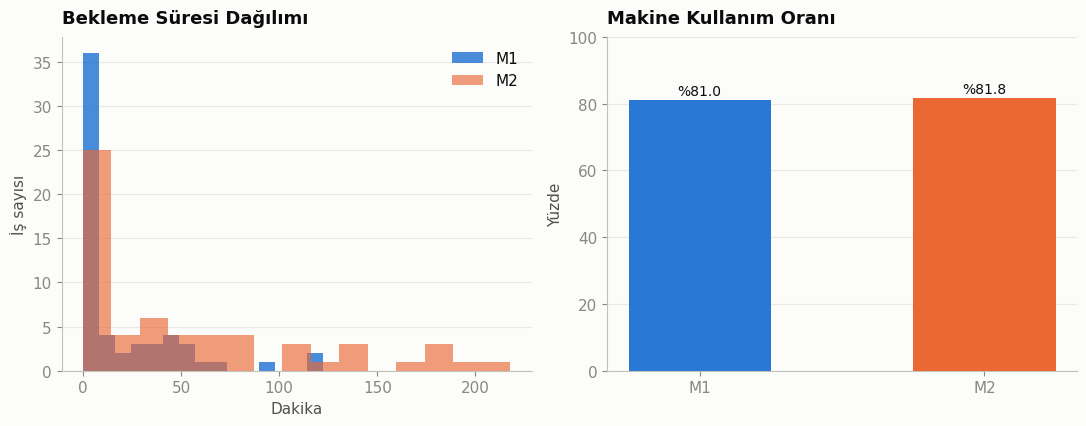

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].hist(df_sim["M1_wait"], bins=15, color=CATEGORICAL[0], alpha=0.85, label="M1")
axes[0].hist(df_sim["M2_wait"], bins=15, color=CATEGORICAL[1], alpha=0.65, label="M2")
style_ax(axes[0], "Bekleme Süresi Dağılımı", "Dakika", "İş sayısı")
axes[0].legend()

util = [busy_time["M1"]/sim_end*100, busy_time["M2"]/sim_end*100]
bars = axes[1].bar(["M1", "M2"], util, color=[CATEGORICAL[0], CATEGORICAL[1]], width=0.5)
for b, v in zip(bars, util):
    axes[1].text(b.get_x()+b.get_width()/2, v+1.5, f"%{v:.1f}", ha="center", fontsize=10)
style_ax(axes[1], "Makine Kullanım Oranı", None, "Yüzde")
axes[1].set_ylim(0, 100)
fig.tight_layout()
plt.show()




### 3.1 Tekrarlanabilir bir simülasyon fonksiyonu

Adım 4-5'te RL ortamını kurarken ve farklı politikaları karşılaştırırken bu simülasyonu defalarca
çalıştıracağız. O yüzden şimdi her şeyi tek bir fonksiyona sarıyoruz

In [56]:
def run_baseline_simulation(n_jobs=60, interarrival=100, seed=42):
    """RL olmadan, sabit varsayımlarla çalışan iki makineli hat simülasyonu.
    Geriye (df, metrics) döndürür."""
    random.seed(seed)
    env = simpy.Environment()
    m1 = simpy.Resource(env, capacity=1)
    m2 = simpy.Resource(env, capacity=1)
    log, busy_time = [], {"M1": 0.0, "M2": 0.0}
    env.process(job_generator(env, m1, m2, log, busy_time, n_jobs=n_jobs, interarrival=interarrival))
    env.run()
    sim_end = env.now
    df = pd.DataFrame(log)
    metrics = {
        "avg_M1_wait": float(df["M1_wait"].mean()),
        "avg_M2_wait": float(df["M2_wait"].mean()),
        "avg_flow_time": float(df["flow_time"].mean()),
        "M1_utilization_pct": float(busy_time["M1"]/sim_end*100),
        "M2_utilization_pct": float(busy_time["M2"]/sim_end*100),
        "throughput_per_hour": float(len(df)/(sim_end/60)),
        "M1_failed_pct": float((df["M1_outcome"]=="Failed").mean()*100),
        "M2_failed_pct": float((df["M2_outcome"]=="Failed").mean()*100),
    }
    return df, metrics

# Dogrulama: ayni seed ile ayni sonucu vermeli (reproducibility kontrolu)
_df_check, _m_check = run_baseline_simulation()
assert abs(_m_check["avg_flow_time"] - baseline_metrics["avg_flow_time"]) < 1e-9
print("run_baseline_simulation() dogrulandi - onceki sonuclarla birebir ayni.")


run_baseline_simulation() dogrulandi - onceki sonuclarla birebir ayni.


### 3.2 Kendi Parametrelerinle İnteraktif Deneme

Şimdiye kadar sabit, veriden türetilmiş değerlerle çalıştık. Ama bir simülasyonun asıl gücü
şurada: **"ya X olsaydı?" sorusunu sorabilmek.** Ya varış sıklığı iki katına çıksa? Ya
makineler daha güvenilir olsaydı (arıza olasılığı düşük olsa)? Ya onarım süresi kısalsaydı?

Bunu Colab'a özel bir özellikle yapacağız: bir kod hücresine `#@param` yorumu eklersen, Colab
o satırı otomatik olarak bir **form alanına** (kaydırma çubuğu, metin kutusu) çeviriyor —
kodu hiç değiştirmeden değerleri düzenleyip tekrar çalıştırabiliyorsun. Kodun kendisi
tamamen normal Python; `#@param` sadece bir yorum satırı, Colab'ın arayüzü onu özel
yorumluyor (bu yüzden Colab dışında da sorunsuz çalışır, sadece formu göremezsin).

Aşağıdaki hücreyi çalıştırdığında sağında kaydırma çubukları çıkacak. Değerleri değiştirip
hücreyi tekrar çalıştırdıkça farklı senaryoları deneyebilirsin.

In [57]:
# @markdown Simülasyon Parametreleri —değerleri değiştirip hücreyi çalıştır
N_JOBS_OZEL = 40  #@param {type:"slider", min:10, max:200, step:10}
INTERARRIVAL_OZEL = 55  #@param {type:"slider", min:10, max:300, step:5}
PROC_MIN_OZEL = 20  #@param {type:"integer"}
PROC_MAX_OZEL = 120  #@param {type:"integer"}
P_FAILED_OZEL = 0.06  #@param {type:"slider", min:0, max:0.5, step:0.01}
P_DELAYED_OZEL = 0.04  #@param {type:"slider", min:0, max:0.5, step:0.01}
DELAY_MIN_OZEL = 10  #@param {type:"integer"}
DELAY_MAX_OZEL = 30  #@param {type:"integer"}
REPAIR_MIN_OZEL = 45  #@param {type:"integer"}
REPAIR_MAX_OZEL = 90  #@param {type:"integer"}
SEED_OZEL = 42  #@param {type:"integer"}


Şimdi bu parametreleri kullanan, **bağımsız** bir simülasyon fonksiyonu yazıyoruz — bu
fonksiyon Adım 2'deki `job`/`station` fonksiyonlarına dokunmuyor, onlardan tamamen ayrı
çalışıyor. Böylece daha önce eklediğin hücreleri bozma riski olmuyor.

Ayrıca, Adım 2.4'te öğrendiğimiz **trafik yoğunluğu (ρ)** kontrolünü otomatik olarak
yapıyoruz — eğer girdiğin değerler kuyruğu kararsız hale getirecekse (ρ ≥ 1), seni
uyaracağız.

In [58]:
def run_custom_simulation(n_jobs, interarrival, seed, proc_min, proc_max,
                           p_failed, p_delayed, delay_min, delay_max,
                           repair_min, repair_max):
    p_completed = 1 - p_failed - p_delayed
    if p_completed < 0:
        raise ValueError("P_FAILED_OZEL + P_DELAYED_OZEL 1'i geçemez!")
    status_probs = {"Completed": p_completed, "Delayed": p_delayed, "Failed": p_failed}

    def sample_proc():
        return random.uniform(proc_min, proc_max)

    def sample_outcome():
        return random.choices(list(status_probs.keys()), weights=list(status_probs.values()))[0]

    def station_o(env, name, resource, row, busy_time):
        arrive = env.now
        with resource.request() as req:
            yield req
            wait = env.now - arrive
            t = sample_proc()
            yield env.timeout(t)
            outcome = sample_outcome()
            extra = 0.0
            if outcome == "Delayed":
                extra = random.uniform(delay_min, delay_max); yield env.timeout(extra)
            elif outcome == "Failed":
                extra = random.uniform(repair_min, repair_max); yield env.timeout(extra)
        busy_time[name] += (t + extra)
        row[f"{name}_wait"] = wait; row[f"{name}_outcome"] = outcome

    def job_o(env, jname, m1, m2, log, busy_time):
        row = {"name": jname, "arrive": env.now}
        yield from station_o(env, "M1", m1, row, busy_time)
        yield from station_o(env, "M2", m2, row, busy_time)
        row["leave"] = env.now
        row["flow_time"] = row["leave"] - row["arrive"]
        log.append(row)

    def gen_o(env, m1, m2, log, busy_time):
        for i in range(n_jobs):
            env.process(job_o(env, f"İş-{i+1}", m1, m2, log, busy_time))
            yield env.timeout(interarrival)

    random.seed(seed)
    env = simpy.Environment()
    m1 = simpy.Resource(env, capacity=1)
    m2 = simpy.Resource(env, capacity=1)
    log, busy_time = [], {"M1": 0.0, "M2": 0.0}
    env.process(gen_o(env, m1, m2, log, busy_time))
    env.run()
    sim_end = env.now
    df = pd.DataFrame(log)
    metrics = {
        "avg_M1_wait": df["M1_wait"].mean(),
        "avg_M2_wait": df["M2_wait"].mean(),
        "avg_flow_time": df["flow_time"].mean(),
        "M1_utilization_pct": busy_time["M1"] / sim_end * 100,
        "M2_utilization_pct": busy_time["M2"] / sim_end * 100,
        "throughput_per_hour": len(df) / (sim_end / 60),
        "M1_failed_pct": (df["M1_outcome"] == "Failed").mean() * 100,
        "M2_failed_pct": (df["M2_outcome"] == "Failed").mean() * 100,
    }
    return df, metrics, sim_end, busy_time


# --- Trafik yoğunluğu (ρ) kontrolü - Adım 2.4'teki dersi hatırla ---
mean_proc = (PROC_MIN_OZEL + PROC_MAX_OZEL) / 2
mean_delay = (DELAY_MIN_OZEL + DELAY_MAX_OZEL) / 2
mean_repair = (REPAIR_MIN_OZEL + REPAIR_MAX_OZEL) / 2
E_service_ozel = mean_proc + P_DELAYED_OZEL * mean_delay + P_FAILED_OZEL * mean_repair
rho_ozel = E_service_ozel / INTERARRIVAL_OZEL
if rho_ozel >= 1:
    print(f"UYARI: ρ={rho_ozel:.2f} ≥ 1 -> kuyruk KARARSIZ olacak, bekleme süreleri sınırsız büyüyebilir!")
else:
    print(f"ρ={rho_ozel:.2f} (kararlı bir sistem)")

# --- Simülasyonu çalıştır ---
df_ozel, metrics_ozel, sim_end_ozel, busy_ozel = run_custom_simulation(
    N_JOBS_OZEL, INTERARRIVAL_OZEL, SEED_OZEL,
    PROC_MIN_OZEL, PROC_MAX_OZEL,
    P_FAILED_OZEL, P_DELAYED_OZEL,
    DELAY_MIN_OZEL, DELAY_MAX_OZEL,
    REPAIR_MIN_OZEL, REPAIR_MAX_OZEL,
)

print("\n--- Senin Parametrelerinle Sonuçlar ---")
for k, v in metrics_ozel.items():
    print(f"{k:25s}: {v:.2f}")


UYARI: ρ=1.36 ≥ 1 -> kuyruk KARARSIZ olacak, bekleme süreleri sınırsız büyüyebilir!

--- Senin Parametrelerinle Sonuçlar ---
avg_M1_wait              : 430.21
avg_M2_wait              : 72.61
avg_flow_time            : 643.51
M1_utilization_pct       : 97.21
M2_utilization_pct       : 85.40
throughput_per_hour      : 0.78
M1_failed_pct            : 12.50
M2_failed_pct            : 2.50


Ve sonuçları görselleştirelim — tıpkı Adım 3'teki gibi.

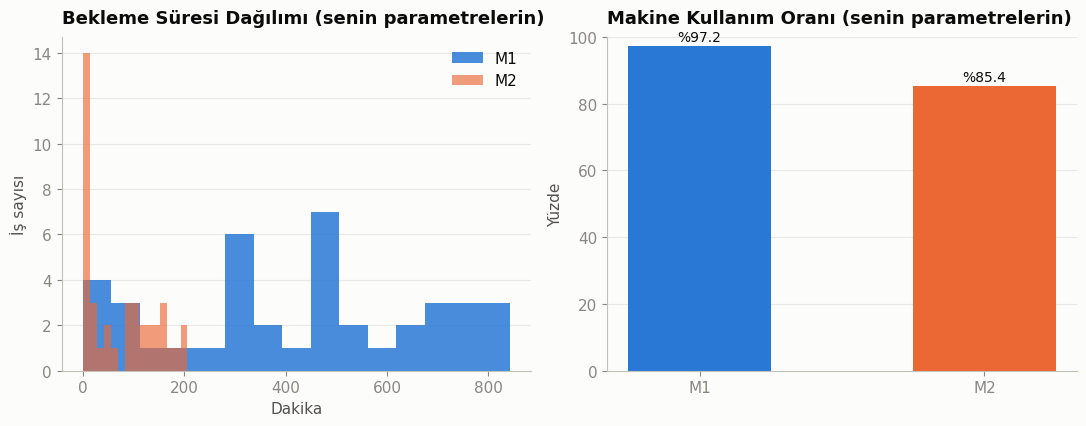

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].hist(df_ozel["M1_wait"], bins=15, color=CATEGORICAL[0], alpha=0.85, label="M1")
axes[0].hist(df_ozel["M2_wait"], bins=15, color=CATEGORICAL[1], alpha=0.65, label="M2")
style_ax(axes[0], "Bekleme Süresi Dağılımı (senin parametrelerin)", "Dakika", "İş sayısı")
axes[0].legend()

util_ozel = [busy_ozel["M1"]/sim_end_ozel*100, busy_ozel["M2"]/sim_end_ozel*100]
bars = axes[1].bar(["M1", "M2"], util_ozel, color=[CATEGORICAL[0], CATEGORICAL[1]], width=0.5)
for b, v in zip(bars, util_ozel):
    axes[1].text(b.get_x()+b.get_width()/2, v+1.5, f"%{v:.1f}", ha="center", fontsize=10)
style_ax(axes[1], "Makine Kullanım Oranı (senin parametrelerin)", None, "Yüzde")
axes[1].set_ylim(0, 100)
fig.tight_layout()
plt.show()


Artık yukarıdaki form alanına dönüp örneğin `INTERARRIVAL_OZEL`'i 50'ye düşürüp (daha sık
varış) ya da `P_FAILED_OZEL`'i 0.05'e çekip (daha güvenilir makine) tekrar çalıştırabilirsin —
sonuçların nasıl değiştiğini anında görürsün. Bu, Adım 5'te RL ajanını değerlendirirken de
işimize yarayacak: "RL ajanı, farklı senaryolarda da iyi performans gösteriyor mu?" sorusunu
aynı mantıkla test edebileceğiz.

---

## 4. Bakım Kararı için RL Ortamı (Gymnasium)

### 4.1 Pekiştirmeli öğrenmenin (RL) mantığı

Bir köpeğe itaat eğitimi verdiğini düşün: köpek bir hareket yapar (**aksiyon**), sen ona ödül
ya da hiçbir şey vermezsin (**ödül**), köpek zamanla hangi hareketin daha çok ödül getirdiğini
öğrenir (**politika**). RL de aynı mantık — bir **ajan**, bir **ortamda** (environment)
bulunur, her adımda bir **aksiyon** seçer, ortam ona yeni bir **durum (state/observation)** ve
bir **ödül (reward)** döndürür. Ajan, binlerce deneme sonunda toplam ödülü maksimize eden
stratejiyi öğrenir.

**Gymnasium** kütüphanesi, bu tür ortamları standart bir kalıpla tanımlamamızı sağlıyor:

- `env.reset()` → simülasyonu başa sar, başlangıç durumunu döndür
- `env.step(aksiyon)` → bir adım ilerlet, `(yeni_durum, ödül, bitti_mi, ...)` döndür

Önce çok basitleştirilmiş, "oyuncak" bir ortamla mantığı görelim:

In [60]:
import gymnasium as gym
from gymnasium import spaces

class ToyMaintenanceEnv(gym.Env):
    """Çok basitleştirilmiş bir 'bakım kararı' ortamı - sadece mantığı göstermek için."""
    def __init__(self):
        super().__init__()
        self.action_space = spaces.Discrete(2)              # 0=devam et, 1=bakım yap
        self.observation_space = spaces.Box(low=0, high=15, shape=(1,), dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.wear = 0
        return np.array([self.wear], dtype=np.float32), {}

    def step(self, action):
        if action == 1:                       # bakım yap
            reward = -5                       # bakım maliyeti (zaman kaybı)
            self.wear = 0
        else:                                 # devam et
            p_fail = min(0.05 + 0.03 * self.wear, 0.6)   # aşınma arttıkça arıza riski artar
            if random.random() < p_fail:
                reward = -30                  # arıza cezası
                self.wear = 0                 # arıza sonrası onarım aşınmayı da sıfırlar
            else:
                reward = +10                  # başarılı tamamlama
                self.wear += 1
        obs = np.array([self.wear], dtype=np.float32)
        return obs, reward, False, False, {}


random.seed(0)
toy_env = ToyMaintenanceEnv()
obs, info = toy_env.reset()
print(f"Başlangıç: obs(aşınma)={obs}")

total_reward = 0
for i in range(10):
    action = random.choice([0, 1])   # şimdilik rastgele bir "politika"
    obs, reward, terminated, truncated, info = toy_env.step(action)
    total_reward += reward
    aksiyon_adi = "BAKIM" if action == 1 else "devam"
    print(f"adım {i+1}: aksiyon={aksiyon_adi:>5}  -> yeni aşınma={obs[0]:.0f}  ödül={reward:+.0f}")

print("\nToplam ödül:", total_reward)


Başlangıç: obs(aşınma)=[0.]
adım 1: aksiyon=BAKIM  -> yeni aşınma=0  ödül=-5
adım 2: aksiyon=BAKIM  -> yeni aşınma=0  ödül=-5
adım 3: aksiyon=devam  -> yeni aşınma=1  ödül=+10
adım 4: aksiyon=BAKIM  -> yeni aşınma=0  ödül=-5
adım 5: aksiyon=BAKIM  -> yeni aşınma=0  ödül=-5
adım 6: aksiyon=BAKIM  -> yeni aşınma=0  ödül=-5
adım 7: aksiyon=BAKIM  -> yeni aşınma=0  ödül=-5
adım 8: aksiyon=BAKIM  -> yeni aşınma=0  ödül=-5
adım 9: aksiyon=devam  -> yeni aşınma=1  ödül=+10
adım 10: aksiyon=BAKIM  -> yeni aşınma=0  ödül=-5

Toplam ödül: -20


- **Durum (state)**: makinenin "aşınması" — son bakımdan/arızadan bu yana kaç iş
  işlediği. 0'dan başlıyor.
- **Aksiyon**: 0 = üretime devam et, 1 = bakım yap.
- **Ödül**: devam edip başarılı olursan +10, arıza olursa -30, bakım yaparsan -5 (zaman kaybı).
- Aşınma arttıkça arıza riski büyüyor — yani hiç bakım yapmadan sürekli devam etmek gitgide
  riskli hale geliyor.

Rastgele aksiyonlarla (henüz öğrenme yok) 10 adım attık — amaç, ajanın bu stratejiyi
öğrenerek toplam ödülü artırmayı öğrenmesi.

### 4.2 Önemli bir modelleme kararı: aşınma (wear) varsayımı

Adım 1'de veride şunu bulmuştuk: **arıza olasılığı hiçbir şeye bağlı değildi** — sabit
%12.9, makineden/operasyondan/geçmişten bağımsızdı (ki-kare testiyle kanıtlamıştık). Bu,
gerçekte doğru bir bulgu ama bizim için bir sorun yaratıyor: **eğer arıza riski hiç
değişmiyorsa, "önleyici bakım" kararının hiçbir faydası olmaz** — ne zaman bakım yaparsan yap,
risk hep aynı kalır, RL'nin öğreneceği bir şey olmaz.

Bu yüzden, onarım süresinde yaptığımız gibi, burada da açıkça belirtilen bir **modelleme
varsayımı** ekliyoruz: makinenin son bakımdan/arızadan bu yana işlediği iş sayısı (aşınma)
arttıkça arıza riskinin de arttığını varsayıyoruz. Bu, bakım/güvenilirlik literatüründe yaygın
bir yaklaşım (aşınma ile artan arıza oranı) ve RL'nin öğrenecek gerçek bir şeyi olmasını
sağlıyor.

**Kapsam:** MVP'de bakım kararını sadece **M1** için kuruyoruz (basit tutmak için); M2'ye aynı
mantığı eklemek ileride kolay bir genişletme.

### 4.3 Gerçek ortam: `M1MaintenanceEnv`

Şimdi gerçek ortamımızı kuruyoruz. Süreç (bir iş için):

1. Ajan aksiyon seçer: devam et (0) ya da bakım yap (1).
2. Bakım seçildiyse: `Uniform(15,30)` dk bakım süresi geçer, aşınma sıfırlanır (onarımdan
   daha kısa çünkü planlı/öngörülebilir bir bakım).
3. İş işlenir: `Uniform(20,120)` dk (Adım 1'den), arıza olasılığı aşınmaya bağlı
   (`min(0.05 + 0.03·aşınma, 0.6)`).
4. Sonuç: Failed → onarım (`Uniform(45,90)` dk) + aşınma sıfırlanır + ödül bonusu yok;
   Delayed → ek `Uniform(10,30)` dk + aşınma +1 + ödül +40; Completed → aşınma +1 + ödül +100.
5. **Ödül** = (tamamlanma bonusu) − (o adımda harcanan toplam süre). Yani ajan hem işi
   başarıyla bitirmeyi hem de zamanı verimli kullanmayı (gereksiz bakım yapmamayı, ama arızaya
   da yol açmamayı) öğrenmek zorunda.

In [61]:
# --- Adım 1-2'den gelen (ampirik) parametreler ---
P_DELAYED_GIVEN_NOT_FAILED = 0.198 / (1 - 0.129)   # ampirik orandan türetildi (~0.227)

# --- Adım 4'te eklenen VARSAYIMLAR (aşınma/bakım modellemesi için) ---
MAINT_MIN, MAINT_MAX = 15, 30      # önleyici bakım süresi (onarımdan daha kısa)
BASE_FAIL = 0.05
WEAR_SLOPE = 0.03
MAX_FAIL = 0.6
WEAR_CAP = 15                       # gözlem uzayı üst sınırı
N_JOBS_RL = 60

class M1MaintenanceEnv(gym.Env):
    def __init__(self):
        super().__init__()
        self.action_space = spaces.Discrete(2)   # 0=devam, 1=bakım
        self.observation_space = spaces.Box(low=0, high=WEAR_CAP, shape=(1,), dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.wear = 0
        self.job_idx = 0
        return np.array([self.wear], dtype=np.float32), {}

    def step(self, action):
        time_spent = 0.0
        if action == 1:                                  # önleyici bakım
            time_spent += random.uniform(MAINT_MIN, MAINT_MAX)
            self.wear = 0

        p_fail = min(BASE_FAIL + WEAR_SLOPE * self.wear, MAX_FAIL)
        time_spent += random.uniform(PROC_MIN, PROC_MAX)

        if random.random() < p_fail:
            outcome = "Failed"
            time_spent += random.uniform(REPAIR_MIN, REPAIR_MAX)
            self.wear = 0
            bonus = 0
        elif random.random() < P_DELAYED_GIVEN_NOT_FAILED:
            outcome = "Delayed"
            time_spent += random.uniform(DELAY_MIN, DELAY_MAX)
            self.wear = min(self.wear + 1, WEAR_CAP)
            bonus = 40
        else:
            outcome = "Completed"
            self.wear = min(self.wear + 1, WEAR_CAP)
            bonus = 100

        reward = bonus - time_spent
        self.job_idx += 1
        terminated = self.job_idx >= N_JOBS_RL
        obs = np.array([self.wear], dtype=np.float32)
        info = {"outcome": outcome, "action": action, "time_spent": time_spent}
        return obs, reward, terminated, False, info


### 4.4 Sağlık kontrolü: sabit politikalarla karşılaştırma

RL ajanını eğitmeden önce, birkaç basit **sabit politika** deneyelim — bunlar hem ortamın
doğru çalıştığını doğrulamamıza yarar hem de RL'nin geçmesi gereken bir "alt sınır" oluşturur.
5 farklı basit strateji deniyoruz: hiç bakım yapma, her zaman bakım yap, 3 işte bir / 5 işte
bir periyodik bakım, ve "aşınma 5'e ulaşınca bakım yap" (eşik tabanlı).

In [62]:
def run_fixed_policy(policy_fn, n_episodes=200, seed0=0):
    env = M1MaintenanceEnv()
    ep_rewards, ep_failures = [], []
    for ep in range(n_episodes):
        random.seed(seed0 + ep)
        obs, _ = env.reset()
        total_r, n_fail = 0.0, 0
        done = False
        step_i = 0
        while not done:
            action = policy_fn(step_i, obs)
            obs, r, done, trunc, info = env.step(action)
            total_r += r
            if info["outcome"] == "Failed":
                n_fail += 1
            step_i += 1
        ep_rewards.append(total_r)
        ep_failures.append(n_fail)
    return np.mean(ep_rewards), np.std(ep_rewards), np.mean(ep_failures)

fixed_policies = {
    "hic_bakim_yapma":        lambda i, o: 0,
    "her_zaman_bakim_yap":    lambda i, o: 1,
    "periyodik_3_iste_bir":   lambda i, o: 1 if (i % 3 == 0) else 0,
    "periyodik_5_iste_bir":   lambda i, o: 1 if (i % 5 == 0) else 0,
    "esik_asinma_5_bakim":    lambda i, o: 1 if o[0] >= 5 else 0,
}

fixed_policy_results = {}
print(f"{'Politika':<24} {'Ort. Ödül/Bölüm':>16} {'Std':>8} {'Ort. Arıza sayısı':>18}")
for name, fn in fixed_policies.items():
    m, s, f = run_fixed_policy(fn)
    fixed_policy_results[name] = {"avg_reward": m, "std_reward": s, "avg_failures": f}
    print(f"{name:<24} {m:>16.1f} {s:>8.1f} {f:>18.2f}")


Politika                  Ort. Ödül/Bölüm      Std  Ort. Arıza sayısı
hic_bakim_yapma                    -659.2    372.6               9.21
her_zaman_bakim_yap               -1024.0    411.0               2.87
periyodik_3_iste_bir               -415.7    486.3               4.67
periyodik_5_iste_bir               -447.5    447.3               5.96
esik_asinma_5_bakim                -389.0    389.2               6.28


**Ödülün işareti (negatif olması) önemli değil** — çünkü her adımda geçen süreyi
doğrudan ödülden çıkarıyoruz, bu yüzden mükemmel bir politika bile 0'a yakın çıkar, negatife
değil. Önemli olan **politikalar arasındaki sıralama**: hangisi en az negatif (en verimli)?

Sonuçlarda dikkat çeken şey: "hiç bakım yapma" ile "her zaman bakım yap" ikisi de kötü —
biri çok fazla arızaya yol açıyor, diğeri gereksiz yere çok fazla zaman harcıyor. **Eşik
tabanlı** politika (aşınma 5'e ulaşınca bakım yap) genelde bu ikisinden daha iyi çıkıyor,
çünkü *duruma göre* karar veriyor. RL'nin görevi de tam olarak bu — sabit bir kural yerine,
durumu (aşınmayı) gözlemleyip en uygun kararı **öğrenerek** bulmak. Sıradaki adımda bunu
yapacağız.

---

**Sıradaki adım (Adım 5):** `M1MaintenanceEnv` ortamını kullanarak bir RL ajanı eğiteceğiz.
Durum uzayımız küçük ve ayrık olduğu için (aşınma 0-15 arası tam sayı), yorumlanması kolay
bir yöntemle başlayacağız: **tablo tabanlı Q-learning** — her (durum, aksiyon) çifti için bir
"değer" tutan ve deneme-yanılmayla bu tabloyu güncelleyen klasik bir RL algoritması. Eğitilmiş
ajanı yukarıdaki sabit politikalarla ve baseline ile karşılaştıracağız.